# 18. Своя функция потерь и своя метрика: недооценка в 3 раза дороже переоценки

| | |
|---|---|
| **Уровень** | 3 из 4 — средние данные: полный цикл и типовые случаи (`3_medium`) |
| **Скрипт-источник** | [`18_custom_loss_and_metric.py`](../18_custom_loss_and_metric.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 4 с |

**Цель.** Обучить бустинг под бизнес-цену ошибки, а не под стандартную MSE.

### Чему вы научитесь

- Вывести g и h асимметричной потери и проверить их численно
- Передать их в XGBoost и LightGBM
- Своя метрика для ранней остановки
- Ловушки LightGBM: старт с нуля, `init_score`, встроенная метрика

### Данные

`_data.make_houses` — 20 000 квартир; цель — `log(цены)`. Сценарий: оценщик залога, для которого недооценка квартиры (упущенная сделка) в 3 раза дороже переоценки.

### План

1. **Этап 1.** Данные (цель — логарифм цены)
2. **Этап 2.** Потеря: r = y − F; при недооценке (r > 0) штраф α·r²/2, иначе r²/2
3. **Этап 3.** XGBoost (sklearn-интерфейс): objective и eval_metric — наши функции
4. **Этап 4.** LightGBM: init_score, metric='None' и прибавление старта к прогнозу
5. **Этап 5.** Сравнение с обычной MSE-моделью
6. **Этап 6.** Выводы

> Ноутбук собран из `examples/3_medium/18_custom_loss_and_metric.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_houses

ex = Example(EXAMPLES / "3_medium/18_custom_loss_and_metric.py", title="18. Своя потеря и своя метрика",
             goal="обучить бустинг под асимметричную цену ошибки")

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from gbcourse.style import ROLE

ALPHA = 3.0

## Этап 1. Данные (цель — логарифм цены)

In [2]:
X, price = make_houses(ex.size(20_000, 4000), seed=18)
y = np.log(price)
ex.describe(X, y, target="log(цена)", source="examples/_data.py → make_houses")
n = len(y)
perm = np.random.default_rng(0).permutation(n)
tr, va, te = perm[: int(0.6 * n)], perm[int(0.6 * n): int(0.8 * n)], perm[int(0.8 * n):]

   Источник: examples/_data.py → make_houses
   Объектов: 20 000   признаков: 10   память: 1.26 МБ
   Типы признаков: int64 × 5, float64 × 3, category × 2
   Пропуски: кухня 5.0%
   Цель «log(цена)»: среднее 2.068, σ 0.476, мин 0.015, макс 3.544
   Первые строки:


,площадь,комнаты,этаж,этажность,год,до_центра_км,район,парковка,ремонт,кухня,[log(цена)]
0,44.9,2,4,5,1957,6.18,район_02,1,косметический,6.4,1.786747
1,38.7,2,2,5,2000,11.75,район_09,1,евро,7.7,2.072669
2,24.1,1,5,9,1985,5.67,район_01,0,косметический,5.0,1.357123


## Этап 2. Потеря: r = y − F; при недооценке (r > 0) штраф α·r²/2, иначе r²/2

In [3]:
def grad_hess(y_true, y_pred):
    r = y_true - y_pred
    return np.where(r > 0, -ALPHA * r, -r), np.where(r > 0, ALPHA, 1.0)


def cost(y_true, y_pred):
    r = y_true - y_pred
    return float(np.mean(0.5 * np.where(r > 0, ALPHA, 1.0) * r * r))


yy, FF, eps = np.array([1.0]), 0.6, 1e-5                           # численная проверка производных
L = lambda f: cost(yy, np.array([f]))
g, h = grad_hess(yy, np.array([FF]))
print(f"   g = {g[0]:+.4f} (численно {(L(FF + eps) - L(FF - eps)) / (2 * eps):+.4f}); "
      f"h = {h[0]:.4f} (численно {(L(FF + eps) - 2 * L(FF) + L(FF - eps)) / eps ** 2:.4f})")
F0 = float(np.quantile(y[tr], ALPHA / (1 + ALPHA)))                # разумный старт — верхний квантиль

   g = -1.2000 (численно -1.2000); h = 3.0000 (численно 3.0000)


## Этап 3. XGBoost (sklearn-интерфейс): objective и eval_metric — наши функции

In [4]:
xm = xgb.XGBRegressor(n_estimators=3000, learning_rate=0.05, max_depth=6, objective=grad_hess, eval_metric=cost,
                      base_score=F0, enable_categorical=True, tree_method="hist", early_stopping_rounds=100,
                      disable_default_eval_metric=True)
xm.fit(X.iloc[tr], y[tr], eval_set=[(X.iloc[va], y[va])], verbose=False)
p_x = xm.predict(X.iloc[te])
print(f"   лучшая итерация {xm.best_iteration}; асимметричная цена на тесте {cost(y[te], p_x):.5f}")

   лучшая итерация 210; асимметричная цена на тесте 0.00671


## Этап 4. LightGBM: init_score, metric='None' и прибавление старта к прогнозу

In [5]:
lm = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.05, num_leaves=31, objective=grad_hess, metric="None", verbose=-1)
lm.fit(X.iloc[tr], y[tr], init_score=np.full(len(tr), F0), eval_X=(X.iloc[va],), eval_y=(y[va],),
       eval_init_score=[np.full(len(va), F0)], eval_metric=lambda a, b: ("asym", cost(a, b), False),
       callbacks=[lgb.early_stopping(100, verbose=False)])
p_l = lm.predict(X.iloc[te]) + F0                  # init_score в модель не сохраняется!
print(f"   лучшая итерация {lm.best_iteration_}; асимметричная цена на тесте {cost(y[te], p_l):.5f}")
ex.note("""Три ловушки LightGBM: своя цель стартует с нуля (нужен init_score); init_score не входит в predict;
встроенная метрика не отключается сама (metric='None'), иначе ранняя остановка пойдёт по ней.""")

   лучшая итерация 254; асимметричная цена на тесте 0.00655


> ▸ **Вывод.** Три ловушки LightGBM: своя цель стартует с нуля (нужен init\_score); init\_score не входит в predict; встроенная метрика не отключается сама (metric='None'), иначе ранняя остановка пойдёт по ней.

## Этап 5. Сравнение с обычной MSE-моделью

   MSE (обычная)            цена 0.00788; доля недооценок 51.0%; средний сдвиг прогноза +0.3%
   асимметричная, XGBoost   цена 0.00671; доля недооценок 37.2%; средний сдвиг прогноза +3.2%
   асимметричная, LightGBM  цена 0.00655; доля недооценок 36.8%; средний сдвиг прогноза +3.3%


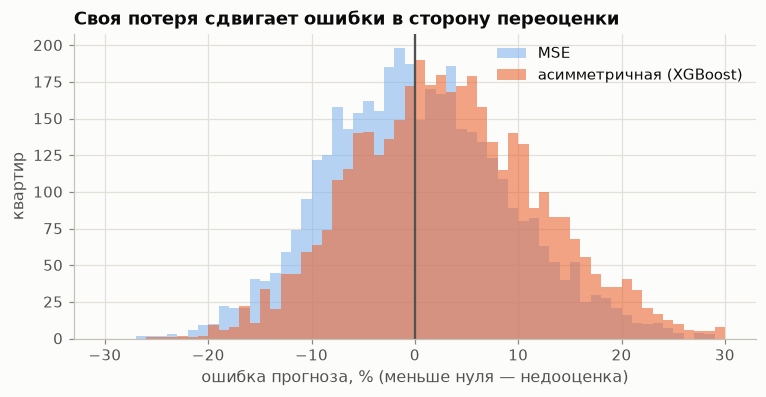

In [6]:
ms = xgb.XGBRegressor(n_estimators=3000, learning_rate=0.05, max_depth=6, enable_categorical=True, tree_method="hist",
                      early_stopping_rounds=100).fit(X.iloc[tr], y[tr], eval_set=[(X.iloc[va], y[va])], verbose=False)
p_s = ms.predict(X.iloc[te])
for name, p in (("MSE (обычная)", p_s), ("асимметричная, XGBoost", p_x), ("асимметричная, LightGBM", p_l)):
    under = np.mean(y[te] > p)
    print(f"   {name:24s} цена {cost(y[te], p):.5f}; доля недооценок {under:.1%}; средний сдвиг прогноза {np.mean(np.exp(p) / price[te] - 1):+.1%}")
assert cost(y[te], p_x) < cost(y[te], p_s)
fig, ax = plt.subplots(figsize=(8, 3.6))
bins = np.linspace(-30, 30, 61)
for name, p, c in (("MSE", p_s, ROLE["model_prev"]), ("асимметричная (XGBoost)", p_x, ROLE["tree"])):
    ax.hist(100 * (np.exp(p - y[te]) - 1), bins=bins, color=c, alpha=0.6, label=name)
ax.axvline(0, color=ROLE["data"], lw=1.5)
ax.set(xlabel="ошибка прогноза, % (меньше нуля — недооценка)", ylabel="квартир",
       title="Своя потеря сдвигает ошибки в сторону переоценки")
ax.legend()
ex.finish(fig, "18_error_shift")

## Этап 6. Выводы

In [7]:
ex.note("""Своя потеря сдвигает прогноз вверх (в среднем на ~3%) настолько, насколько выгодно при цене ошибок 3:1: доля недооценок
падает с 51% до 37%, а асимметричная цена — на 15–17%. MSE-модель оптимальна для MSE, а не для бизнеса.""")
ex.done()

> ▸ **Вывод.** Своя потеря сдвигает прогноз вверх (в среднем на ~3%) настолько, насколько выгодно при цене ошибок 3:1: доля недооценок падает с 51% до 37%, а асимметричная цена — на 15–17%. MSE-модель оптимальна для MSE, а не для бизнеса.

Готово за 2.1 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Поставьте ALPHA = 1 (симметричный случай) — совпадёт ли модель с обычной MSE?
2. Уберите `init_score` у LightGBM и посмотрите, как меняются число деревьев и цена ошибок.
3. Реализуйте асимметричную абсолютную потерю и сравните со встроенной `objective="quantile".`

## Что дальше

- **Теория в курсе:** [10.3 «Свои потери»](../../../lessons/lesson_10_3/README.md), [8.1 «Тейлор: g и h»](../../../lessons/lesson_8_1/README.md).
- **Предыдущий пример:** [17. Редкий класс (1%): метрики, веса классов, порог и бюджет](17_imbalanced_classes.ipynb)
- **Следующий пример:** [19. Настройка гиперпараметров: кросс-валидация LightGBM и поиск Optuna](19_cv_and_optuna.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)